# Advanced Topic Modeling Analysis

This notebook initializes the analysis environment by loading topic-modeling output tables into pandas DataFrames.

In [40]:
from __future__ import annotations
import json
from pathlib import Path

import pandas as pd
from IPython.display import display
pd.set_option("display.max_columns", 120)

In [41]:
# Resolve project root from either repository root or notebooks directory.
project_root = Path.cwd()
if not (project_root / "outputs").exists() and project_root.name == "notebooks":
    project_root = project_root.parent

output_dir = project_root / "outputs" / "topic_modeling"
tables_dir = output_dir / "tables"
figures_dir = output_dir / "figures"

print(f"Project root: {project_root}")
print(f"Tables dir:   {tables_dir}")
print(f"Figures dir:  {figures_dir}")

Project root: c:\Users\Alonso\Dropbox\personal\repos\chilean-humor
Tables dir:   c:\Users\Alonso\Dropbox\personal\repos\chilean-humor\outputs\topic_modeling\tables
Figures dir:  c:\Users\Alonso\Dropbox\personal\repos\chilean-humor\outputs\topic_modeling\figures


In [42]:
def read_table(path: Path) -> pd.DataFrame | None:
    """Read a CSV table if present; return None when missing."""
    if not path.exists():
        print(f"Missing table: {path}")
        return None
    return pd.read_csv(path)


topic_info_df = read_table(tables_dir / "topic_info.csv")
topics_over_time_df = read_table(tables_dir / "topics_over_time.csv")
segments_topics_df = read_table(tables_dir / "segments_topics.csv")
hierarchical_topics_df = read_table(tables_dir / "hierarchical_topics.csv")

tables = {
    "topic_info": topic_info_df,
    "topics_over_time": topics_over_time_df,
    "segments_topics": segments_topics_df,
    "hierarchical_topics": hierarchical_topics_df,
}

loaded_tables = {name: df for name, df in tables.items() if df is not None}
print(f"Loaded {len(loaded_tables)} table(s): {', '.join(loaded_tables.keys())}")

Loaded 4 table(s): topic_info, topics_over_time, segments_topics, hierarchical_topics


In [43]:
run_report_path = output_dir / "run_report.json"
run_report = {}

if run_report_path.exists():
    with run_report_path.open("r", encoding="utf-8") as f:
        run_report = json.load(f)
    print(f"Loaded run report: {run_report_path}")
else:
    print(f"Run report not found: {run_report_path}")

Loaded run report: c:\Users\Alonso\Dropbox\personal\repos\chilean-humor\outputs\topic_modeling\run_report.json


In [44]:
for name, df in loaded_tables.items():
    print(f"\\n{name}: shape={df.shape}")
    display(df.head(3))

\ntopic_info: shape=(31, 5)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1,-1____,"['', '', '', '', '', '', '', '', '', '']",['Yo ahora para finalizar antes de volver nuev...
1,0,358,0_presidente_país_huevón_pesos,"['presidente', 'país', 'huevón', 'pesos', 'pol...",['Hablemos Hablemos del Boris. ¿Quieren hablar...
2,1,285,1_canción_almas_cantar_vivo vivo,"['canción', 'almas', 'cantar', 'vivo vivo', 'm...","['Vamos con la palma, el estilo mira que no me..."


\ntopics_over_time: shape=(168, 4)


,Topic,Words,Frequency,Timestamp
0,-1,", , , ,",1,1970
1,0,"1000 pesos, 300 pesos, 1000, 300, pesos",4,1970
2,1,"vivo vivo, vivo, canción, cigarrillos, sueltos",23,1970


\nsegments_topics: shape=(4568, 22)


,id,segment_idx,show,year,date,festival,event_name,youtube_url,start_time_seconds,end_time_seconds,duration_seconds,text,source_row_index,model_text,model_decade,topic_initial,topic_final,topic_name_initial,topic_name_final,is_outlier_initial,is_outlier_final,max_topic_probability
0,24,0,Edmundo Arrocet,1971,1971-02-02,XII,Festival Internacional de la Canción de Viña d...,https://www.youtube.com/watch?v=makiS7Xf5vs,8.0,24.0,16.0,"Por favor, oraciosos a ella. De inmediato, a c...",0,"Por favor, oraciosos a ella. De inmediato, a c...",1970,-1,3,-1____,3_humor_quinta_quinta vergara_vergara,True,False,0.093180
1,24,1,Edmundo Arrocet,1971,1971-02-02,XII,Festival Internacional de la Canción de Viña d...,https://www.youtube.com/watch?v=makiS7Xf5vs,33.0,89.0,56.0,"Señora, señora, andiamo a interpretar una canz...",1,"Señora, señora, andiamo a interpretar una canz...",1970,-1,8,-1____,8_anthony_amas_your_you,True,False,0.071609
2,24,2,Edmundo Arrocet,1971,1971-02-02,XII,Festival Internacional de la Canción de Viña d...,https://www.youtube.com/watch?v=makiS7Xf5vs,91.0,123.0,32.0,"Y paso tras paso, yo la buscaré y la encontrar...",2,"Y paso tras paso, yo la buscaré y la encontrar...",1970,8,8,8_anthony_amas_your_you,8_anthony_amas_your_you,False,False,0.096469


\nhierarchical_topics: shape=(29, 8)


,Parent_ID,Parent_Name,Topics,Child_Left_ID,Child_Left_Name,Child_Right_ID,Child_Right_Name,Distance
0,58,va_bien_cómo_bueno_dice,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",56,quinta_vergara_quinta vergara_humor_escenario,57,dijo_dice_dije_ay_voy,1.362075
1,57,dijo_dice_dije_ay_voy,"[0, 1, 2, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 1...",55,dijo_dije_dice_huevón_voy,53,ay ay_salta salta_ay_salta_mosca,0.927165
2,56,quinta_vergara_quinta vergara_humor_escenario,"[3, 6, 14, 17, 19, 21, 22]",50,muchas_buenas noches_noches_verdad_buenas,46,quinta_vergara_quinta vergara_humor_escenario,0.871921


In [45]:
# Central in-memory container for downstream analysis cells.
analysis_data = {
    "topic_info": topic_info_df,
    "topics_over_time": topics_over_time_df,
    "segments_topics": segments_topics_df,
    "hierarchical_topics": hierarchical_topics_df,
    "run_report": run_report,
    "paths": {
        "project_root": project_root,
        "output_dir": output_dir,
        "tables_dir": tables_dir,
        "figures_dir": figures_dir,
    },
}

analysis_data.keys()

dict_keys(['topic_info', 'topics_over_time', 'segments_topics', 'hierarchical_topics', 'run_report', 'paths'])

## Decade Coverage and Comparability

Start by checking how many segments are available per decade and whether decades are reasonably comparable.

In [46]:
coverage_df = (
    segments_topics_df.groupby('model_decade', dropna=False)
    .size()
    .rename('n_segments')
    .reset_index()
    .sort_values('model_decade')
)
coverage_df['share_pct'] = coverage_df['n_segments'] / coverage_df['n_segments'].sum() * 100

shows_per_decade_df = (
    segments_topics_df.groupby('model_decade')['show']
    .nunique()
    .rename('n_shows')
    .reset_index()
)
coverage_df = coverage_df.merge(shows_per_decade_df, on='model_decade', how='left')
coverage_df['segments_per_show'] = coverage_df['n_segments'] / coverage_df['n_shows']

display(coverage_df.style.format({'share_pct': '{:.2f}', 'segments_per_show': '{:.2f}'}))

max_min_ratio = coverage_df['n_segments'].max() / coverage_df['n_segments'].min()
cv_segments = coverage_df['n_segments'].std() / coverage_df['n_segments'].mean()

print(f'Max/Min segments ratio: {max_min_ratio:.2f}x')
print(f'Coefficient of variation (segments): {cv_segments:.3f}')

,model_decade,n_segments,share_pct,n_shows,segments_per_show
0,1970,141,3.09,8,17.62
1,1980,66,1.44,4,16.50
2,1990,677,14.82,21,32.24
3,2000,889,19.46,25,35.56
4,2010,1756,38.44,37,47.46
5,2020,1039,22.75,20,51.95


Max/Min segments ratio: 26.61x
Coefficient of variation (segments): 0.822


Text(0.5, 1.0, 'Segments per Decade')

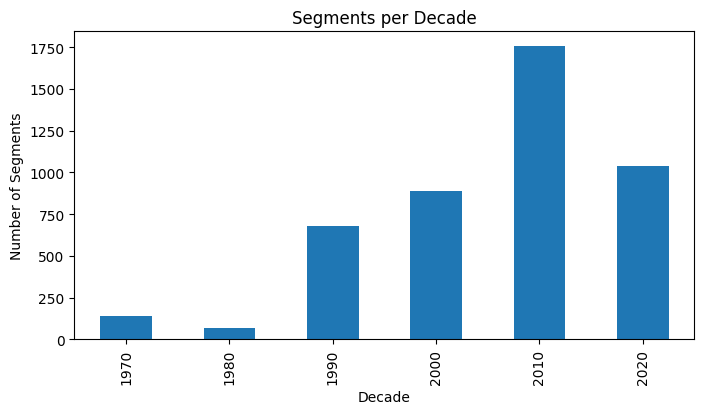

In [47]:
# Optional quick chart for visual inspection of imbalance across decades.
ax = coverage_df.plot.bar(x='model_decade', y='n_segments', legend=False, figsize=(8, 4))
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Segments')
ax.set_title('Segments per Decade')

## Topic Prevalence Normalized by Time

Compute topic prevalence normalized by the number of segments available in each time bucket.
Default time bucket is decade (`model_decade`).

In [48]:
# You can switch to 'year' or 'date' later if needed.
time_col = 'model_decade'
topic_col = 'topic_final'
topic_name_col = 'topic_name_final'
exclude_outliers = True
outlier_topic_id = -1

prevalence_input_df = segments_topics_df.copy()
if exclude_outliers:
    prevalence_input_df = prevalence_input_df[
        prevalence_input_df[topic_col] != outlier_topic_id
    ].copy()

counts_df = (
    prevalence_input_df.groupby([time_col, topic_col], dropna=False)
    .size()
    .rename('n_segments')
    .reset_index()
)

totals_df = (
    prevalence_input_df.groupby(time_col, dropna=False)
    .size()
    .rename('total_segments')
    .reset_index()
)

topic_labels_df = (
    prevalence_input_df[[topic_col, topic_name_col]]
    .dropna()
    .drop_duplicates(subset=[topic_col])
    .rename(columns={topic_name_col: 'topic_name'})
)

prevalence_df = (
    counts_df
    .merge(totals_df, on=time_col, how='left')
    .merge(topic_labels_df, on=topic_col, how='left')
)
prevalence_df['prevalence_pct'] = (
    prevalence_df['n_segments'] / prevalence_df['total_segments'] * 100
)
prevalence_df = prevalence_df.sort_values(
    [time_col, 'prevalence_pct'],
    ascending=[True, False],
).reset_index(drop=True)

display(prevalence_df.head(20))

,model_decade,topic_final,n_segments,total_segments,topic_name,prevalence_pct
0,1970,1,23,140,1_canción_almas_cantar_vivo vivo,16.428571
1,1970,8,14,140,8_anthony_amas_your_you,10.000000
2,1970,3,12,140,3_humor_quinta_quinta vergara_vergara,8.571429
3,1970,9,10,140,9_auto_dijo dijo_micro_carabineros,7.142857
4,1970,19,9,140,19_través_mar_viña_viña mar,6.428571
5,1970,10,8,140,10_maestro_hora hora_ruperto_hora,5.714286
6,1970,12,7,140,12_perro_perrito_selva_lobo,5.000000
7,1970,4,6,140,4_chileno_chile_argentino_chilenos,4.285714
8,1970,2,5,140,2_chiste_programa_hoy hoy_chistes,3.571429
9,1970,5,5,140,5_colegio_niños_papá_hijo,3.571429


In [49]:
top_k_per_time = 10
top_topics_by_time_df = (
    prevalence_df.groupby(time_col, group_keys=False)
    .head(top_k_per_time)
)

display(
    top_topics_by_time_df[[
        time_col,
        topic_col,
        'topic_name',
        'n_segments',
        'total_segments',
        'prevalence_pct',
    ]].style.format({'prevalence_pct': '{:.2f}'})
)

,model_decade,topic_final,topic_name,n_segments,total_segments,prevalence_pct
0,1970,1,1_canción_almas_cantar_vivo vivo,23,140,16.43
1,1970,8,8_anthony_amas_your_you,14,140,10.00
2,1970,3,3_humor_quinta_quinta vergara_vergara,12,140,8.57
3,1970,9,9_auto_dijo dijo_micro_carabineros,10,140,7.14
4,1970,19,19_través_mar_viña_viña mar,9,140,6.43
5,1970,10,10_maestro_hora hora_ruperto_hora,8,140,5.71
6,1970,12,12_perro_perrito_selva_lobo,7,140,5.00
7,1970,4,4_chileno_chile_argentino_chilenos,6,140,4.29
8,1970,2,2_chiste_programa_hoy hoy_chistes,5,140,3.57
9,1970,5,5_colegio_niños_papá_hijo,5,140,3.57


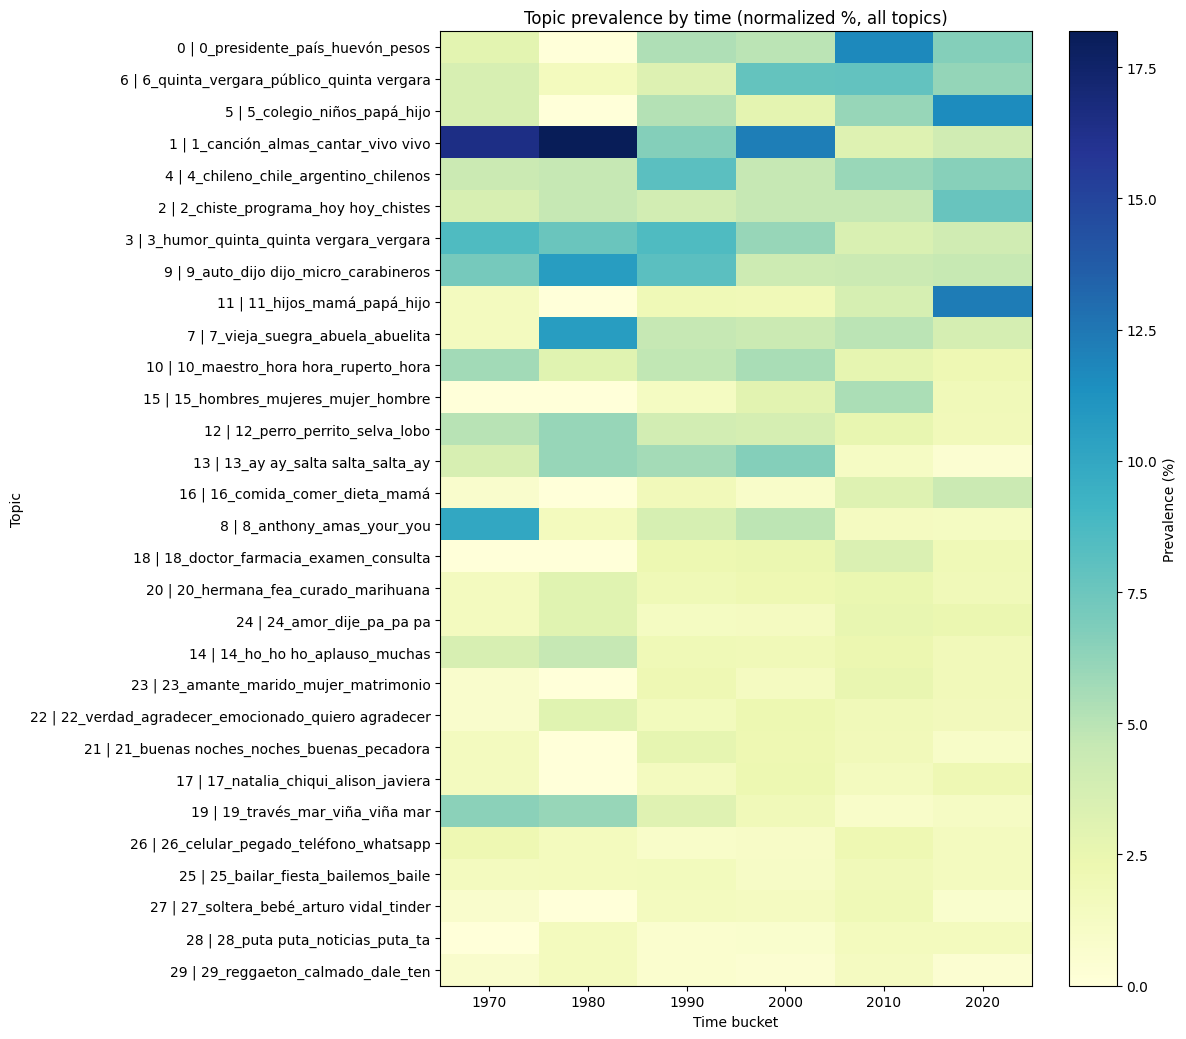

In [50]:
import matplotlib.pyplot as plt
import numpy as np

topic_totals_df = (
    prevalence_input_df[topic_col]
    .value_counts()
    .rename_axis(topic_col)
    .reset_index(name='n_total')
)

# Set to an integer (e.g., 20) to limit rows; keep None to plot all topics.
max_topics_to_plot = None
if max_topics_to_plot is None:
    selected_topic_ids = topic_totals_df[topic_col].tolist()
    title_suffix = 'all topics'
else:
    selected_topic_ids = topic_totals_df.head(max_topics_to_plot)[topic_col].tolist()
    title_suffix = f'top {max_topics_to_plot} topics'

prevalence_matrix_df = (
    prevalence_df.pivot(index=topic_col, columns=time_col, values='prevalence_pct')
    .fillna(0.0)
)
prevalence_matrix_plot_df = prevalence_matrix_df.reindex(selected_topic_ids).fillna(0.0)

topic_name_map = (
    prevalence_df[[topic_col, 'topic_name']]
    .drop_duplicates(subset=[topic_col])
    .set_index(topic_col)['topic_name']
    .to_dict()
)
row_labels = [
    f"{topic_id} | {topic_name_map.get(topic_id, 'unknown')}"
    for topic_id in prevalence_matrix_plot_df.index
]

fig, ax = plt.subplots(figsize=(12, max(6, len(row_labels) * 0.35)))
im = ax.imshow(prevalence_matrix_plot_df.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(np.arange(len(prevalence_matrix_plot_df.columns)))
ax.set_xticklabels(prevalence_matrix_plot_df.columns)
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_xlabel('Time bucket')
ax.set_ylabel('Topic')
ax.set_title(f'Topic prevalence by time (normalized %, {title_suffix})')

colorbar = fig.colorbar(im, ax=ax)
colorbar.set_label('Prevalence (%)')
plt.tight_layout()


In [51]:
analysis_data['topic_prevalence_by_time'] = prevalence_df
analysis_data['topic_prevalence_matrix_plot'] = prevalence_matrix_plot_df
analysis_data['top_topics_by_time'] = top_topics_by_time_df

list(analysis_data.keys())


['topic_info',
 'topics_over_time',
 'segments_topics',
 'hierarchical_topics',
 'run_report',
 'paths',
 'topic_prevalence_by_time',
 'topic_prevalence_matrix_plot',
 'top_topics_by_time']

## Topic Similarity Across Shows

Build a normalized `show x topic` matrix and compare shows using cosine similarity.

In [52]:
show_col = 'show'
topic_col = 'topic_final'
topic_name_col = 'topic_name_final'
exclude_outliers = True
outlier_topic_id = -1
min_segments_per_show = 15

show_topic_input_df = segments_topics_df.copy()
if exclude_outliers:
    show_topic_input_df = show_topic_input_df[
        show_topic_input_df[topic_col] != outlier_topic_id
    ].copy()

show_segment_counts_df = (
    show_topic_input_df.groupby(show_col)
    .size()
    .rename('n_segments')
    .reset_index()
    .sort_values('n_segments', ascending=False)
)

eligible_shows = show_segment_counts_df.loc[
    show_segment_counts_df['n_segments'] >= min_segments_per_show, show_col
].tolist()

show_topic_filtered_df = show_topic_input_df[
    show_topic_input_df[show_col].isin(eligible_shows)
].copy()

show_topic_counts_df = pd.crosstab(
    show_topic_filtered_df[show_col],
    show_topic_filtered_df[topic_col],
)

# Row-normalized matrix: each row sums to 1.0 for topic prevalence within a show.
show_topic_matrix_df = show_topic_counts_df.div(show_topic_counts_df.sum(axis=1), axis=0)

print(f'Eligible shows: {len(eligible_shows)} / {show_segment_counts_df[show_col].nunique()}')
print(f'Matrix shape (shows x topics): {show_topic_matrix_df.shape}')
display(show_segment_counts_df.head(10))
display(show_topic_matrix_df.head(5))

Eligible shows: 78 / 90
Matrix shape (shows x topics): (78, 30)


,show,n_segments
16,Dinamita Show,188
72,Pedro Ruminot,175
11,Coco Legrand,155
65,Palta Meléndez,138
6,Bombo Fica,133
19,Edo Caroe,131
17,Dino Gordillo,130
45,Juan Pablo López,126
31,Gloria Benavides,112
14,"Daniela ""Chiqui"" Aguayo",109


topic_final,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
show,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Alejandra Azcárate,0.000000,0.000000,0.031250,0.000000,0.000000,0.000000,0.125000,0.093750,0.000000,0.000000,0.000000,0.218750,0.031250,0.031250,0.000000,0.187500,0.000000,0.031250,0.000000,0.000000,0.000000,0.0,0.000000,0.093750,0.000000,0.000000,0.000000,0.125000,0.031250,0.0
Alex Ortiz,0.000000,0.000000,0.000000,0.022727,0.000000,0.386364,0.068182,0.045455,0.000000,0.000000,0.000000,0.159091,0.022727,0.022727,0.000000,0.000000,0.090909,0.000000,0.090909,0.045455,0.000000,0.0,0.022727,0.000000,0.000000,0.000000,0.022727,0.000000,0.000000,0.0
Alison Mandel,0.057471,0.000000,0.034483,0.011494,0.011494,0.045977,0.057471,0.057471,0.022989,0.057471,0.000000,0.183908,0.011494,0.000000,0.000000,0.045977,0.034483,0.114943,0.011494,0.011494,0.034483,0.0,0.034483,0.045977,0.011494,0.000000,0.011494,0.091954,0.000000,0.0
Arturo Ruiz-Tagle,0.109375,0.031250,0.078125,0.015625,0.078125,0.046875,0.078125,0.031250,0.000000,0.093750,0.031250,0.015625,0.078125,0.031250,0.000000,0.078125,0.031250,0.000000,0.000000,0.000000,0.000000,0.0,0.015625,0.015625,0.046875,0.031250,0.015625,0.000000,0.046875,0.0
Bastián Paz,0.027778,0.055556,0.166667,0.027778,0.000000,0.055556,0.083333,0.000000,0.000000,0.000000,0.055556,0.055556,0.083333,0.000000,0.027778,0.083333,0.111111,0.027778,0.055556,0.027778,0.000000,0.0,0.000000,0.000000,0.027778,0.027778,0.000000,0.000000,0.000000,0.0


In [53]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

show_names = show_topic_matrix_df.index.tolist()
similarity_matrix = cosine_similarity(show_topic_matrix_df.values)
show_similarity_df = pd.DataFrame(
    similarity_matrix,
    index=show_names,
    columns=show_names,
)

triu_i, triu_j = np.triu_indices_from(similarity_matrix, k=1)
pairwise_similarity_df = pd.DataFrame({
    'show_a': [show_names[i] for i in triu_i],
    'show_b': [show_names[j] for j in triu_j],
    'cosine_similarity': similarity_matrix[triu_i, triu_j],
}).sort_values('cosine_similarity', ascending=False)

top_pairs_to_display = 30
top_similarity_pairs_df = pairwise_similarity_df.head(top_pairs_to_display).copy()

display(top_similarity_pairs_df.style.format({'cosine_similarity': '{:.3f}'}))

,show_a,show_b,cosine_similarity
2317,Juan Pablo López,Palta Meléndez,0.902
480,Bombo Fica,Juan Pablo López,0.897
1960,Hugo Varela,Rudy Rey,0.895
842,"Daniel Muñoz ""El Carmelo""",Payahop,0.887
845,"Daniel Muñoz ""El Carmelo""",Profesor Salomón y Tutu-Tutu,0.886
3002,Álvaro Salas,Óscar Gangas,0.885
2885,Payahop,Profesor Salomón y Tutu-Tutu,0.881
1502,Felo,Payahop,0.880
1955,Hugo Varela,Profesor Salomón y Tutu-Tutu,0.879
207,Alison Mandel,Natalia Valdebenito,0.878


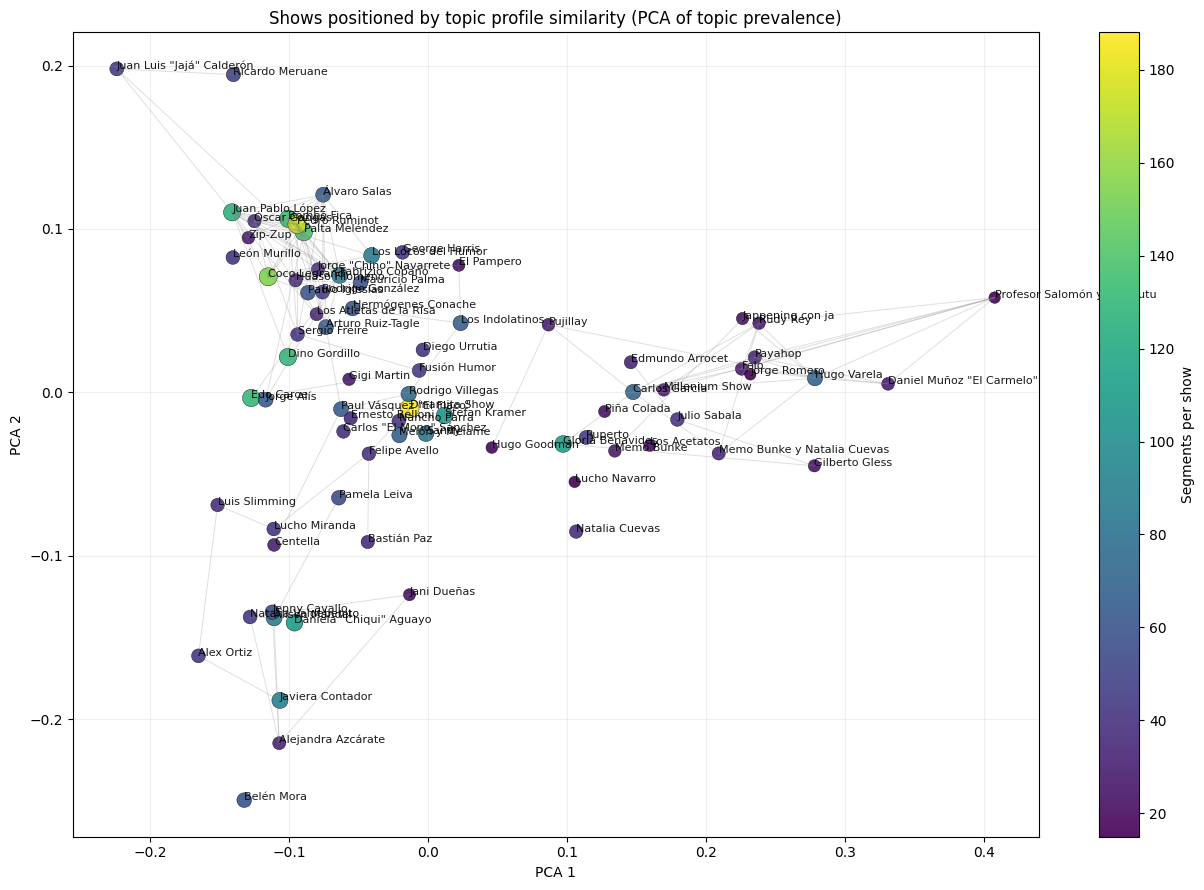

In [54]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_model = PCA(n_components=2, random_state=42)
show_coords = pca_model.fit_transform(show_topic_matrix_df.values)
show_coords_df = pd.DataFrame(show_coords, columns=['x', 'y'], index=show_topic_matrix_df.index)

show_sizes = (
    show_segment_counts_df.set_index(show_col)
    .loc[show_coords_df.index, 'n_segments']
)

edge_similarity_threshold = 0.55
max_edges = 120
annotate_shows = True

edges_to_plot_df = pairwise_similarity_df[
    pairwise_similarity_df['cosine_similarity'] >= edge_similarity_threshold
].head(max_edges)

fig, ax = plt.subplots(figsize=(13, 9))

for _, row in edges_to_plot_df.iterrows():
    a, b = row['show_a'], row['show_b']
    ax.plot(
        [show_coords_df.loc[a, 'x'], show_coords_df.loc[b, 'x']],
        [show_coords_df.loc[a, 'y'], show_coords_df.loc[b, 'y']],
        color='gray',
        alpha=0.25,
        linewidth=0.7,
    )

scatter = ax.scatter(
    show_coords_df['x'],
    show_coords_df['y'],
    s=20 + np.sqrt(show_sizes.values) * 12,
    c=show_sizes.values,
    cmap='viridis',
    alpha=0.9,
    edgecolor='black',
    linewidth=0.3,
)

if annotate_shows:
    for show_name, row in show_coords_df.iterrows():
        ax.text(row['x'], row['y'], show_name, fontsize=8, alpha=0.9)

ax.set_title('Shows positioned by topic profile similarity (PCA of topic prevalence)')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.grid(alpha=0.2)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label('Segments per show')

plt.tight_layout()

In [55]:
analysis_data['show_topic_matrix'] = show_topic_matrix_df
analysis_data['show_similarity_matrix'] = show_similarity_df
analysis_data['show_similarity_pairs'] = pairwise_similarity_df
analysis_data['show_similarity_pairs_top'] = top_similarity_pairs_df
analysis_data['show_similarity_coords'] = show_coords_df

list(analysis_data.keys())

['topic_info',
 'topics_over_time',
 'segments_topics',
 'hierarchical_topics',
 'run_report',
 'paths',
 'topic_prevalence_by_time',
 'topic_prevalence_matrix_plot',
 'top_topics_by_time',
 'show_topic_matrix',
 'show_similarity_matrix',
 'show_similarity_pairs',
 'show_similarity_pairs_top',
 'show_similarity_coords']

## Cross-Era Thematic Influence (Year-Level)

Estimate directed thematic influence from earlier shows to later shows using yearly topic profiles.
A source show can influence a target show only if it appears earlier in time.

In [56]:
import numpy as np
import unicodedata

show_col = 'show'
year_col = 'year'
topic_col = 'topic_final'

exclude_outliers = True
outlier_topic_id = -1
min_segments_per_show = 15
target_early_window_years = 3
min_year_gap = 1
temporal_penalty_strength = 0.25
temporal_penalty_half_life_years = 30

influence_input_df = segments_topics_df.copy()
if exclude_outliers:
    influence_input_df = influence_input_df[
        influence_input_df[topic_col] != outlier_topic_id
    ].copy()

influence_input_df = influence_input_df.dropna(subset=[show_col, year_col, topic_col]).copy()
influence_input_df[year_col] = influence_input_df[year_col].astype(int)

show_counts_df = (
    influence_input_df.groupby(show_col)
    .size()
    .rename('n_segments')
    .reset_index()
)
eligible_shows = show_counts_df.loc[
    show_counts_df['n_segments'] >= min_segments_per_show, show_col
].tolist()

influence_work_df = influence_input_df[
    influence_input_df[show_col].isin(eligible_shows)
].copy()

show_year_topic_counts_df = (
    influence_work_df.groupby([show_col, year_col, topic_col])
    .size()
    .rename('n_segments')
    .reset_index()
)

show_year_topic_matrix_df = show_year_topic_counts_df.pivot_table(
    index=[show_col, year_col],
    columns=topic_col,
    values='n_segments',
    fill_value=0,
)
topic_ids = list(show_year_topic_matrix_df.columns)

show_year_span_df = (
    influence_work_df.groupby(show_col)[year_col]
    .agg(first_year='min', last_year='max', n_years='nunique')
    .reset_index()
    .sort_values('first_year')
)

show_years_map = (
    show_year_span_df.set_index(show_col)[['first_year', 'last_year']]
    .to_dict(orient='index')
)

print(f'Eligible shows: {len(eligible_shows)}')
display(show_year_span_df.head(10))

Eligible shows: 78


,show,first_year,last_year,n_years
16,Edmundo Arrocet,1971,1978,2
43,Los Acetatos,1973,1973,1
30,Hugo Goodman,1974,1974,1
27,Gloria Benavides,1977,2002,4
38,Jorge Romero,1979,1979,1
10,Coco Legrand,1980,2010,4
31,Hugo Varela,1989,2005,2
66,Pujillay,1990,1990,1
58,Palta Meléndez,1991,2007,4
28,Hermógenes Conache,1991,2013,2


In [57]:
def _normalize_vector(vec: np.ndarray) -> np.ndarray:
    total = vec.sum()
    if total <= 0:
        return vec
    return vec / total


def _cosine_sim(vec_a: np.ndarray, vec_b: np.ndarray) -> float:
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(np.dot(vec_a, vec_b) / (norm_a * norm_b))


def aggregate_show_profile(
    show_name: str,
    year_min: int | None = None,
    year_max: int | None = None,
) -> np.ndarray:
    """Aggregate raw topic counts for one show over a year range."""
    try:
        show_slice_df = show_year_topic_matrix_df.loc[show_name]
    except KeyError:
        return np.zeros(len(topic_ids), dtype=float)

    if year_min is not None:
        show_slice_df = show_slice_df[show_slice_df.index >= year_min]
    if year_max is not None:
        show_slice_df = show_slice_df[show_slice_df.index <= year_max]

    if show_slice_df.empty:
        return np.zeros(len(topic_ids), dtype=float)

    return show_slice_df.sum(axis=0).to_numpy(dtype=float)


def topic_idf_weights_before_year(cutoff_year: int) -> np.ndarray:
    """Compute inverse-frequency topic weights using data available before a year."""
    before_df = show_year_topic_counts_df[
        show_year_topic_counts_df[year_col] <= cutoff_year
    ]
    if before_df.empty:
        return np.ones(len(topic_ids), dtype=float)

    topic_counts = before_df.groupby(topic_col)['n_segments'].sum()
    topic_counts = topic_counts.reindex(topic_ids, fill_value=0).to_numpy(dtype=float)
    total = topic_counts.sum()

    # IDF-like weighting: higher for less common topics.
    return np.log((1.0 + total) / (1.0 + topic_counts)) + 1.0

In [58]:
influence_edges = []

for target_show, target_meta in show_years_map.items():
    target_first_year = int(target_meta['first_year'])
    target_last_year = int(target_meta['last_year'])
    target_early_end_year = min(
        target_first_year + target_early_window_years - 1,
        target_last_year,
    )

    target_vec_raw = aggregate_show_profile(
        target_show,
        year_min=target_first_year,
        year_max=target_early_end_year,
    )
    target_vec = _normalize_vector(target_vec_raw)

    idf_weights = topic_idf_weights_before_year(target_first_year - 1)

    for source_show, source_meta in show_years_map.items():
        if source_show == target_show:
            continue

        source_first_year = int(source_meta['first_year'])
        if source_first_year > target_first_year - min_year_gap:
            continue

        source_vec_raw = aggregate_show_profile(
            source_show,
            year_max=target_first_year - 1,
        )
        source_vec = _normalize_vector(source_vec_raw)

        cosine_raw = _cosine_sim(source_vec, target_vec)

        source_vec_weighted = source_vec * idf_weights
        target_vec_weighted = target_vec * idf_weights
        cosine_weighted = _cosine_sim(source_vec_weighted, target_vec_weighted)

        year_gap = target_first_year - source_first_year
        temporal_factor = 0.5 ** (year_gap / temporal_penalty_half_life_years)

        influence_score = cosine_weighted * (
            (1.0 - temporal_penalty_strength)
            + temporal_penalty_strength * temporal_factor
        )

        influence_edges.append({
            'source_show': source_show,
            'target_show': target_show,
            'source_first_year': source_first_year,
            'target_first_year': target_first_year,
            'target_early_end_year': target_early_end_year,
            'year_gap': year_gap,
            'cosine_raw': cosine_raw,
            'cosine_weighted': cosine_weighted,
            'temporal_factor': temporal_factor,
            'influence_score': influence_score,
        })

influence_edges_df = (
    pd.DataFrame(influence_edges)
    .sort_values('influence_score', ascending=False)
    .reset_index(drop=True)
)

top_influencers_per_target = 5
top_influencers_by_target_df = (
    influence_edges_df.groupby('target_show', group_keys=False)
    .head(top_influencers_per_target)
    .reset_index(drop=True)
)

display(
    top_influencers_by_target_df.head(40).style.format({
        'cosine_raw': '{:.3f}',
        'cosine_weighted': '{:.3f}',
        'temporal_factor': '{:.3f}',
        'influence_score': '{:.3f}',
    })
)

,source_show,target_show,source_first_year,target_first_year,target_early_end_year,year_gap,cosine_raw,cosine_weighted,temporal_factor,influence_score
0,Dinamita Show,Melón y Melame,1996,1998,1999,2,0.882,0.871,0.955,0.861
1,Pedro Ruminot,Sergio Freire,2016,2024,2024,8,0.882,0.876,0.831,0.839
2,Hugo Varela,"Daniel Muñoz ""El Carmelo""",1989,2001,2001,12,0.903,0.870,0.758,0.817
3,Bombo Fica,Juan Pablo López,2012,2017,2019,5,0.859,0.830,0.891,0.807
4,Natalia Valdebenito,Alejandra Azcárate,2016,2018,2018,2,0.803,0.815,0.955,0.806
5,Edo Caroe,Juan Pablo López,2016,2017,2019,1,0.856,0.810,0.977,0.805
6,"Daniel Muñoz ""El Carmelo""",Profesor Salomón y Tutu-Tutu,2001,2008,2008,7,0.886,0.832,0.851,0.801
7,Javiera Contador,Alex Ortiz,2020,2024,2024,4,0.828,0.809,0.912,0.791
8,Alejandra Azcárate,Jani Dueñas,2018,2019,2019,1,0.777,0.794,0.977,0.790
9,Profesor Salomón y Tutu-Tutu,Payahop,2008,2014,2014,6,0.881,0.815,0.871,0.789


In [59]:
# Global reference ranking from directed edges.
influencer_ranking_df = (
    influence_edges_df.groupby('source_show')
    .agg(
        n_targets=('target_show', 'nunique'),
        mean_influence_score=('influence_score', 'mean'),
        top10_influence_sum=('influence_score', lambda s: s.nlargest(10).sum()),
    )
    .sort_values(['top10_influence_sum', 'mean_influence_score'], ascending=False)
    .reset_index()
)

best_source_per_target_df = (
    influence_edges_df.groupby('target_show', group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

reference_frequency_df = (
    best_source_per_target_df.groupby('source_show')
    .size()
    .rename('n_targets_as_top_reference')
    .reset_index()
    .sort_values('n_targets_as_top_reference', ascending=False)
)

display(influencer_ranking_df.head(20).style.format({
    'mean_influence_score': '{:.3f}',
    'top10_influence_sum': '{:.3f}',
}))
display(reference_frequency_df.head(20))

,source_show,n_targets,mean_influence_score,top10_influence_sum
0,Hugo Varela,71,0.303,6.849
1,Dinamita Show,57,0.426,6.660
2,Centella,28,0.533,6.527
3,Álvaro Salas,52,0.435,6.521
4,Bombo Fica,39,0.439,6.512
5,Palta Meléndez,68,0.413,6.505
6,Natalia Valdebenito,24,0.448,6.441
7,Óscar Gangas,54,0.390,6.273
8,Pujillay,70,0.409,6.209
9,Arturo Ruiz-Tagle,48,0.425,6.195


,source_show,n_targets_as_top_reference
30,Palta Meléndez,6
29,Natalia Valdebenito,4
21,Javiera Contador,3
18,Hugo Goodman,3
34,Pujillay,3
11,Edmundo Arrocet,3
9,Dinamita Show,3
26,Los Acetatos,3
36,Sandy,3
35,Rodrigo González,3


In [60]:
def normalize_for_match(text: str) -> str:
    text = str(text)
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(ch for ch in text if ord(ch) < 128)
    return text.lower()


def match_show_name(query: str, show_names: list[str]) -> str | None:
    q = normalize_for_match(query)
    matches = [s for s in show_names if q in normalize_for_match(s)]
    if not matches:
        return None
    return sorted(matches, key=len)[0]


source_query = 'salas'
target_query = 'slimming'

show_names = sorted(show_years_map.keys())
source_match = match_show_name(source_query, show_names)
target_match = match_show_name(target_query, show_names)

print('source_match:', source_match)
print('target_match:', target_match)

if source_match and target_match:
    pair_df = influence_edges_df[
        (influence_edges_df['source_show'] == source_match)
        & (influence_edges_df['target_show'] == target_match)
    ]
    display(pair_df.style.format({
        'cosine_raw': '{:.3f}',
        'cosine_weighted': '{:.3f}',
        'temporal_factor': '{:.3f}',
        'influence_score': '{:.3f}',
    }))

    print('Top references for target show:')
    display(
        influence_edges_df[influence_edges_df['target_show'] == target_match]
        .head(10)
        .style.format({
            'cosine_raw': '{:.3f}',
            'cosine_weighted': '{:.3f}',
            'temporal_factor': '{:.3f}',
            'influence_score': '{:.3f}',
        })
    )

source_match: Álvaro Salas
target_match: Luis Slimming


,source_show,target_show,source_first_year,target_first_year,target_early_end_year,year_gap,cosine_raw,cosine_weighted,temporal_factor,influence_score
858,Álvaro Salas,Luis Slimming,2000,2024,2024,24,0.512,0.493,0.574,0.441


Top references for target show:


,source_show,target_show,source_first_year,target_first_year,target_early_end_year,year_gap,cosine_raw,cosine_weighted,temporal_factor,influence_score
40,Javiera Contador,Luis Slimming,2020,2024,2024,4,0.756,0.731,0.912,0.715
90,Centella,Luis Slimming,2015,2024,2024,9,0.704,0.694,0.812,0.662
94,Mauricio Palma,Luis Slimming,2019,2024,2024,5,0.731,0.679,0.891,0.660
131,Felipe Avello,Luis Slimming,2019,2024,2024,5,0.663,0.657,0.891,0.639
206,Pamela Leiva,Luis Slimming,2023,2024,2024,1,0.621,0.608,0.977,0.605
208,Rodrigo Villegas,Luis Slimming,2017,2024,2024,7,0.632,0.627,0.851,0.604
212,"Juan Luis ""Jajá"" Calderón",Luis Slimming,2017,2024,2024,7,0.638,0.627,0.851,0.603
297,Dino Gordillo,Luis Slimming,1996,2024,2024,28,0.676,0.648,0.524,0.571
325,"Paul Vásquez ""El Flaco""",Luis Slimming,2020,2024,2024,4,0.563,0.573,0.912,0.561
333,Fabrizio Copano,Luis Slimming,2017,2024,2024,7,0.620,0.581,0.851,0.559


In [61]:
analysis_data['influence_show_year_spans'] = show_year_span_df
analysis_data['influence_edges'] = influence_edges_df
analysis_data['influence_top_by_target'] = top_influencers_by_target_df
analysis_data['influence_influencer_ranking'] = influencer_ranking_df
analysis_data['influence_reference_frequency'] = reference_frequency_df

list(analysis_data.keys())

['topic_info',
 'topics_over_time',
 'segments_topics',
 'hierarchical_topics',
 'run_report',
 'paths',
 'topic_prevalence_by_time',
 'topic_prevalence_matrix_plot',
 'top_topics_by_time',
 'show_topic_matrix',
 'show_similarity_matrix',
 'show_similarity_pairs',
 'show_similarity_pairs_top',
 'show_similarity_coords',
 'influence_show_year_spans',
 'influence_edges',
 'influence_top_by_target',
 'influence_influencer_ranking',
 'influence_reference_frequency']